# Lib Importing

In [1]:
!pip install langchain_community
!pip install langchain_huggingface
!pip install langchain_groq
!pip install faiss-cpu

In [2]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq

# Preprocessing

In [3]:
import json

with open("hotpot_subset.json") as f:
    data = json.load(f)

contexts = [item["context"] for item in data]
questions = [item["question"] for item in data]
answers = [item["answer"]for item in data]

In [4]:
questions[0]

'Were Scott Derrickson and Ed Wood of the same nationality?'

In [5]:
example= contexts[0]
example

{'title': ['Ed Wood (film)',
  'Scott Derrickson',
  'Woodson, Arkansas',
  'Tyler Bates',
  'Ed Wood',
  'Deliver Us from Evil (2014 film)',
  'Adam Collis',
  'Sinister (film)',
  'Conrad Brooks',
  'Doctor Strange (2016 film)'],
 'sentences': [['Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.',
   " The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.",
   ' Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast.'],
  ['Scott Derrickson (born July 16, 1966) is an American director, screenwriter and producer.',
   ' He lives in Los Angeles, California.',
   ' He is best known for directing horror films such as "Sinister", "The Exorcism of Emily Rose", and "Deliver Us From Evil", as well as the 2016 Marvel Cinematic Univer

In [6]:
def extract_context(example):
    titles = example["title"]
    sentences = example["sentences"]

    docs = []
    for title, sent_list in zip(titles, sentences):
        text = title + " " + " ".join(sent_list)
        docs.append(text)

    return docs

In [7]:
extract_context(example)

["Ed Wood (film) Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.  The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.  Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast.",
 'Scott Derrickson Scott Derrickson (born July 16, 1966) is an American director, screenwriter and producer.  He lives in Los Angeles, California.  He is best known for directing horror films such as "Sinister", "The Exorcism of Emily Rose", and "Deliver Us From Evil", as well as the 2016 Marvel Cinematic Universe installment, "Doctor Strange."',
 'Woodson, Arkansas Woodson is a census-designated place (CDP) in Pulaski County, Arkansas, in the United States.  Its population was 403 at the 2010 census.  It is part of the Little Rock–North Little Rock

In [8]:
type(extract_context(example))

list

In [9]:
all_contexts = []

for item in contexts:
    docs = extract_context(item)
    all_contexts.extend(docs)

In [10]:
all_contexts[0]

"Ed Wood (film) Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.  The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.  Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast."

In [11]:
answers[197]

'Golden Valley, Minnesota,'

# Chunking

In [13]:
from langchain_classic.schema import Document

docs = [Document(page_content=text) for text in all_contexts]

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

chunked_contexts = splitter.split_documents(docs)

# Embedding 

In [12]:
embeddings = HuggingFaceEmbeddings( model_name = "all-MiniLM-L6-V2" )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-V2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
len(chunked_contexts)

16809

In [15]:
chunked_contexts[0]

Document(metadata={}, page_content="Ed Wood (film) Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.  The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.  Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast.")

# VectorStore and Retrieval

In [16]:
import os

FAISS_PATH = "hotpot_faiss_index"

if os.path.exists(FAISS_PATH):
    vectorstore = FAISS.load_local(
        FAISS_PATH,
        embeddings,
        allow_dangerous_deserialization=True
    )
    print("Loaded in seconds!")
else:
    print("Building index, ~12 mins, only once...")
    vectorstore = FAISS.from_documents(chunked_contexts, embeddings)
    vectorstore.save_local(FAISS_PATH)
    print("Built and saved!")

Loaded in seconds!


In [20]:
retriever = vectorstore.as_retriever(search_kwargs={"k":3})

# LLM

In [21]:
from google.colab import userdata
api_key = userdata.get("groq_api_key_2")


llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    api_key=api_key
)

# langgraph (app building)

In [22]:
from typing import TypedDict

class GraphState(TypedDict):
    question: str
    rewritten_query: str
    context: str
    answer: str

In [23]:
def rewrite_query(state):

    question = state["question"]

    prompt = f"""
Rewrite the question to improve document retrieval.

Return ONLY the improved search query.

Question:
{question}

Rewritten query:
"""

    response = llm.invoke(prompt)

    return {"rewritten_query": response.content.strip()}

In [24]:
def retrieve_docs(state):

    query = state["rewritten_query"]

    docs = retriever.invoke(query)

    context = "\n\n".join([doc.page_content for doc in docs])

    return {"context": context}

In [25]:
def generate_answer(state):

    question = state["question"]
    context = state["context"]

    prompt = f"""
You are a question answering system.

Use ONLY the context to answer.

Rules:
- Return ONLY the short answer span.
- Do NOT explain.
- Do NOT write full sentences.
- Answer must be a phrase from the context.

Context:
{context}

Question:
{question}

Answer:
"""

    response = llm.invoke(prompt)

    return {"answer": response.content.strip()}

In [26]:
from langgraph.graph import StateGraph, END

graph = StateGraph(GraphState)

graph.add_node("rewrite", rewrite_query)
graph.add_node("retrieve", retrieve_docs)
graph.add_node("answer", generate_answer)

graph.set_entry_point("rewrite")

graph.add_edge("rewrite", "retrieve")
graph.add_edge("retrieve", "answer")
graph.add_edge("answer", END)

app = graph.compile()

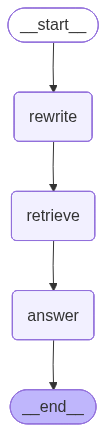

In [27]:
app

In [28]:
questions[2]

'What science fantasy young adult series, told in first person, has a set of companion books narrating the stories of enslaved worlds and alien species?'

In [29]:
answers[2]

'Animorphs'

In [30]:
result = app.invoke({"question": questions[2]})

print(result["answer"])

Animorphs


# Evaluation

In [31]:
predictions=[]

In [48]:
import time


for q in questions[75:100]:

    while True:
        try:
            result = app.invoke({"question": q})
            pred = result["answer"]

            predictions.append(pred)

            time.sleep(5)   # avoid Groq rate limits
            break

        except Exception as e:
            print("Rate limit hit, waiting...")
            time.sleep(15)

In [51]:
predictions

['',
 '',
 'Animorphs',
 'No',
 'Greenwich Village, New York City',
 'YG Entertainment',
 'Eenasul Fateh',
 'Androscoggin Bank\u202fColisée',
 'Annie Morton',
 'American rock band',
 'Kansas Song (We’re From Kansas)',
 'David Weissman',
 '',
 'mixed-use tower',
 'from 1986 to 2013',
 '',
 'North Atlantic Conference',
 'opera composer',
 '',
 'American novelist',
 'Pedro Rodríguez',
 'Miles "Tails" Prower',
 'Macintosh\u202fTV',
 '',
 "the IFFHS World's Best Goalkeeper",
 'Lee Hazlewood',
 '1838',
 'a genus',
 'Henry J. Kaiser',
 'Arena of Khazan',
 'March 14, 2000',
 'Fujioka, Gunma',
 'Charles Nungesser',
 'Australian documentary',
 'Screaming Trees',
 'October\xa01922',
 'since 2000',
 'World War\u202fII',
 'Elko County, Nevada',
 'Columbia University',
 'Scotch Collie',
 'Kochi',
 '1908',
 'ensuring its sovereignty and freedom from colonization',
 'Lyndon Johnson',
 'the Firth of Forth',
 'Phil Spector',
 '',
 'genus of flowering plants',
 'English Electric Canberra',
 '',
 '1,462 h

In [34]:
import re
import string

def normalize_text(text):
    text = text.lower()
    text = re.sub(r'\b(a|an|the)\b', ' ', text)
    text = ''.join(ch for ch in text if ch not in string.punctuation)
    text = ' '.join(text.split())
    return text

## Exact Match

In [35]:
def exact_match_score(prediction, ground_truth):
    return normalize_text(prediction) == normalize_text(ground_truth)

## F1 Score

In [36]:
def f1_score(prediction, ground_truth):

    pred_tokens = normalize_text(prediction).split()
    truth_tokens = normalize_text(ground_truth).split()

    common = set(pred_tokens) & set(truth_tokens)

    if len(common) == 0:
        return 0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(truth_tokens)

    return 2 * (precision * recall) / (precision + recall)

## Eval Func

In [37]:
def evaluate(predictions, subset_ans):

    total = len(predictions)
    exact_match = 0
    f1 = 0

    for pred, truth in zip(predictions, subset_ans):

        if exact_match_score(pred, truth):
            exact_match += 1

        f1 += f1_score(pred, truth)

    exact_match = exact_match / total
    f1 = f1 / total

    return {
        "Exact Match": exact_match,
        "F1 Score": f1
    }

In [49]:
len(predictions)

100

In [52]:
subset_ans=answers[:100]
evaluate(predictions, subset_ans)

{'Exact Match': 0.37, 'F1 Score': 0.4762705627705627}